In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib
import os
import joblib

# STEP 0: ENSURE 'models/' FOLDER EXISTS

os.makedirs("models", exist_ok=True)


# STEP 1: SAVE SCALER

joblib.dump(scaler, "models/scaler_xgb.pkl")

# STEP 0: LOAD CLEANED DATASET

df = pd.read_csv("data/cleaned/final_cleaned_dataset.csv")
print(f"Dataset loaded: {df.shape}")


# STEP 1: DEFINE FEATURES & TARGET

# Drop columns that are not predictors
X = df.drop(columns=["Yield_kg_ha"])  # Features
y = df["Yield_kg_ha"]                 # Target   ------------ principle component analysis ------------ à partir de la courbe cumulative / agent value ; agent vector

# STEP 2: TRAIN / TEST SPLIT (80/20 RANDOM)   Cross validation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


# STEP 3: FEATURE SCALING (Optional)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for later inference
joblib.dump(scaler, "models/scaler_xgb.pkl")



# STEP 4: MODEL INITIALIZATION

xgb_model = XGBRegressor(
    n_estimators=500,       # number of trees
    learning_rate=0.05,     # shrinkage
    max_depth=5,            # tree depth
    subsample=0.8,          # row sampling
    colsample_bytree=0.8,   # feature sampling
    random_state=42
)


# STEP 5: MODEL TRAINING

xgb_model.fit(X_train_scaled, y_train)

# STEP 6: SAVE MODEL

joblib.dump(xgb_model, "models/xgb_yield_model.pkl")
print("\n XGBoost model trained and saved!")

Dataset loaded: (3289, 43)
Train shape: (2631, 42), Test shape: (658, 42)

✅ XGBoost model trained and saved!



=== MODEL PERFORMANCE ===
RMSE  : 524.54 kg/ha
MAE   : 296.28 kg/ha
R²    : 0.9461
MAPE  : 6.68 %


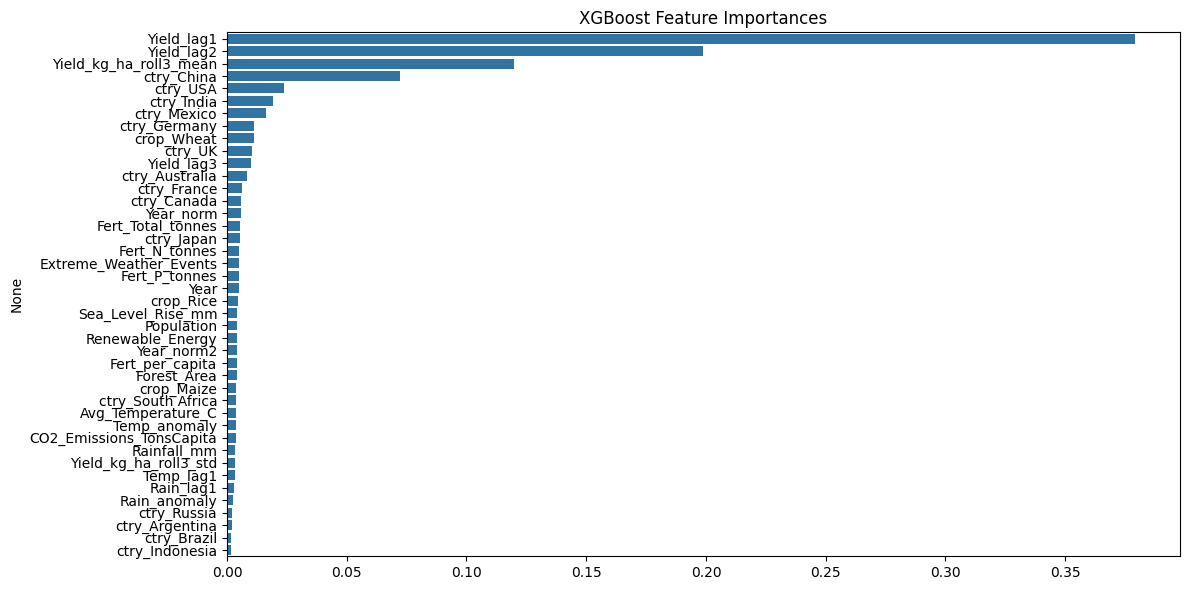

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict on test set
y_pred = xgb_model.predict(X_test_scaled)

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n=== MODEL PERFORMANCE ===")
print(f"RMSE  : {rmse:.2f} kg/ha")
print(f"MAE   : {mae:.2f} kg/ha")
print(f"R²    : {r2:.4f}")
print(f"MAPE  : {mape:.2f} %")

# Optional: Feature importance
import matplotlib.pyplot as plt
import seaborn as sns

fi = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=fi.values, y=fi.index)
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.savefig("models/xgb_feature_importance.png")
plt.show()

In [6]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, xgb_model.predict(X_train_scaled))
r2_test  = r2_score(y_test, xgb_model.predict(X_test_scaled))

print("R² Train:", r2_train)
print("R² Test:", r2_test)

R² Train: 0.9944696567184325
R² Test: 0.9460571373027261
